# PROG8431 - Problem Analysis Workshop A
| Name | Student ID | Sections |
|---|---|---|
| Davisen Veerasamy | 8899632 | Setup, Preprocessing, EDA |
| Carlos Gutierrez | 9118300 | F-Test (6.f), t-Test (6.g) |
| Nnamdi Ikengah | 9085175 | Normality Analysis (6.e) |

**Dataset:** The AI4I 2020 Predictive Maintenance Dataset. It contains 10,000 runs of a milling machine, with five sensor readings per run and a record of whether (and why) the machine failed.

**GitHub Repository:** [https://github.com/DavisenV/Group1-PROG8431-ProblemAnalysis_Workshop_A.git]

## Setup and Configuration

Clone the repository using the above link:
```bash
git clone https://github.com/DavisenV/Group1-PROG8431-ProblemAnalysis_Workshop_A.git
```
Open a terminal and navigate to the root directory
```bash
cd ./"your path here"
```
Create a virtual environment and activate
```bash
python -m venv .venv
.\.venv\Scripts\Activate.ps1
```
Install all the required using the requirements.txt
```bash
python -m pip install -r requirements.txt
```
Run the below code block to import all the required packages and then run each following code block in sequence.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import urllib.request
import zipfile
import os

# Plot styling configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("Environment setup and libraries loaded successfully.")

Environment setup and libraries loaded successfully.


## Download, Load, Preprocess and Clean the Dataset

In [2]:
# Define paths inside a 'data' directory
data_dir = "data"
os.makedirs(data_dir, exist_ok=True)

# UCI AI4I 2020 Predictive Maintenance dataset zip URL
dataset_url = "https://archive.ics.uci.edu/static/public/601/ai4i+2020+predictive+maintenance+dataset.zip"
zip_path = os.path.join(data_dir, "predictive_maintenance.zip")
csv_path = os.path.join(data_dir, "predictive_maintenance.csv")

# Download and extract if not present
if not os.path.exists(csv_path):
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(data_dir)
    print("Extraction complete.")

    extracted_csv_path = os.path.join(data_dir, "ai4i2020.csv")

    if not os.path.exists(extracted_csv_path):
        raise FileNotFoundError(
            f"Expected extracted file was not found: {extracted_csv_path}"
        )

    os.replace(extracted_csv_path, csv_path)
    print(f"Dataset renamed to: {csv_path}")

# Load raw dataset
df = pd.read_csv(csv_path)

# Data Cleaning & Standardization
# 1. Rename columns to cleaner standard Python identifiers
df.columns = [
    'udi', 'product_id', 'type', 'air_temp', 'process_temp', 
    'rotational_speed', 'torque', 'tool_wear', 'machine_failure', 
    'tool_wear_failure', 'heat_dissipation_failure', 'power_failure',
    'overstrain_failure', 'random_failure'
]

# 2. Check and handle missing values & duplicates
missing_count = df.isnull().sum().sum()
duplicate_count = df.duplicated().sum()

# 3. Drop unneeded identification columns for statistical modeling
df_clean = df.drop(columns=['udi', 'product_id']).copy()

# 4. Confirm data types
df_clean['type'] = df_clean['type'].astype('category')
df_clean['machine_failure'] = df_clean['machine_failure'].astype(int)

print(f"Dataset Shape: {df_clean.shape}")
print(f"Missing Values: {missing_count}, Duplicates: {duplicate_count}")
df_clean.head()

Dataset Shape: (10000, 12)
Missing Values: 0, Duplicates: 0


,type,air_temp,process_temp,rotational_speed,torque,tool_wear,machine_failure,tool_wear_failure,heat_dissipation_failure,power_failure,overstrain_failure,random_failure
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Exploratory Data Analysis (EDA)

In [3]:
# Exploratory Data Analysis (EDA)

print("=== 1. Dataset Dimensions & Schema ===")
print(df_clean.info())

print("\n=== 2. Missing Values Check ===")
print(df_clean.isnull().sum())

print("\n=== 3. Summary Statistics for Numeric Features ===")
display(df_clean.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']])

print("\n=== 4. Target Class Distribution (Machine Failure) ===")
failure_counts = df_clean['machine_failure'].value_counts()
failure_percentages = df_clean['machine_failure'].value_counts(normalize=True) * 100
class_dist = pd.DataFrame({'Count': failure_counts, 'Percentage (%)': failure_percentages})
display(class_dist)

print("\n=== 5. Failure Mode Breakdown ===")
failure_modes = [
    'tool_wear_failure', 'heat_dissipation_failure', 'power_failure',
    'overstrain_failure', 'random_failure'
]
display(df_clean[failure_modes].sum().to_frame(name='Failure Occurrences'))

=== 1. Dataset Dimensions & Schema ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   type                      10000 non-null  category
 1   air_temp                  10000 non-null  float64 
 2   process_temp              10000 non-null  float64 
 3   rotational_speed          10000 non-null  int64   
 4   torque                    10000 non-null  float64 
 5   tool_wear                 10000 non-null  int64   
 6   machine_failure           10000 non-null  int64   
 7   tool_wear_failure         10000 non-null  int64   
 8   heat_dissipation_failure  10000 non-null  int64   
 9   power_failure             10000 non-null  int64   
 10  overstrain_failure        10000 non-null  int64   
 11  random_failure            10000 non-null  int64   
dtypes: category(1), float64(3), int64(8)
memory usage: 869.3 KB
None

=== 2. Mi

,mean,std,min,25%,50%,75%,max
air_temp,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
process_temp,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
rotational_speed,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
torque,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
tool_wear,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0
machine_failure,0.03390,0.180981,0.0,0.0,0.0,0.0,1.0
tool_wear_failure,0.00460,0.067671,0.0,0.0,0.0,0.0,1.0
heat_dissipation_failure,0.01150,0.106625,0.0,0.0,0.0,0.0,1.0
power_failure,0.00950,0.097009,0.0,0.0,0.0,0.0,1.0
overstrain_failure,0.00980,0.098514,0.0,0.0,0.0,0.0,1.0



=== 4. Target Class Distribution (Machine Failure) ===


,Count,Percentage (%)
machine_failure,,
0,9661,96.61
1,339,3.39



=== 5. Failure Mode Breakdown ===


,Failure Occurrences
tool_wear_failure,46
heat_dissipation_failure,115
power_failure,95
overstrain_failure,98
random_failure,19


## Histogram of Sensor Readings

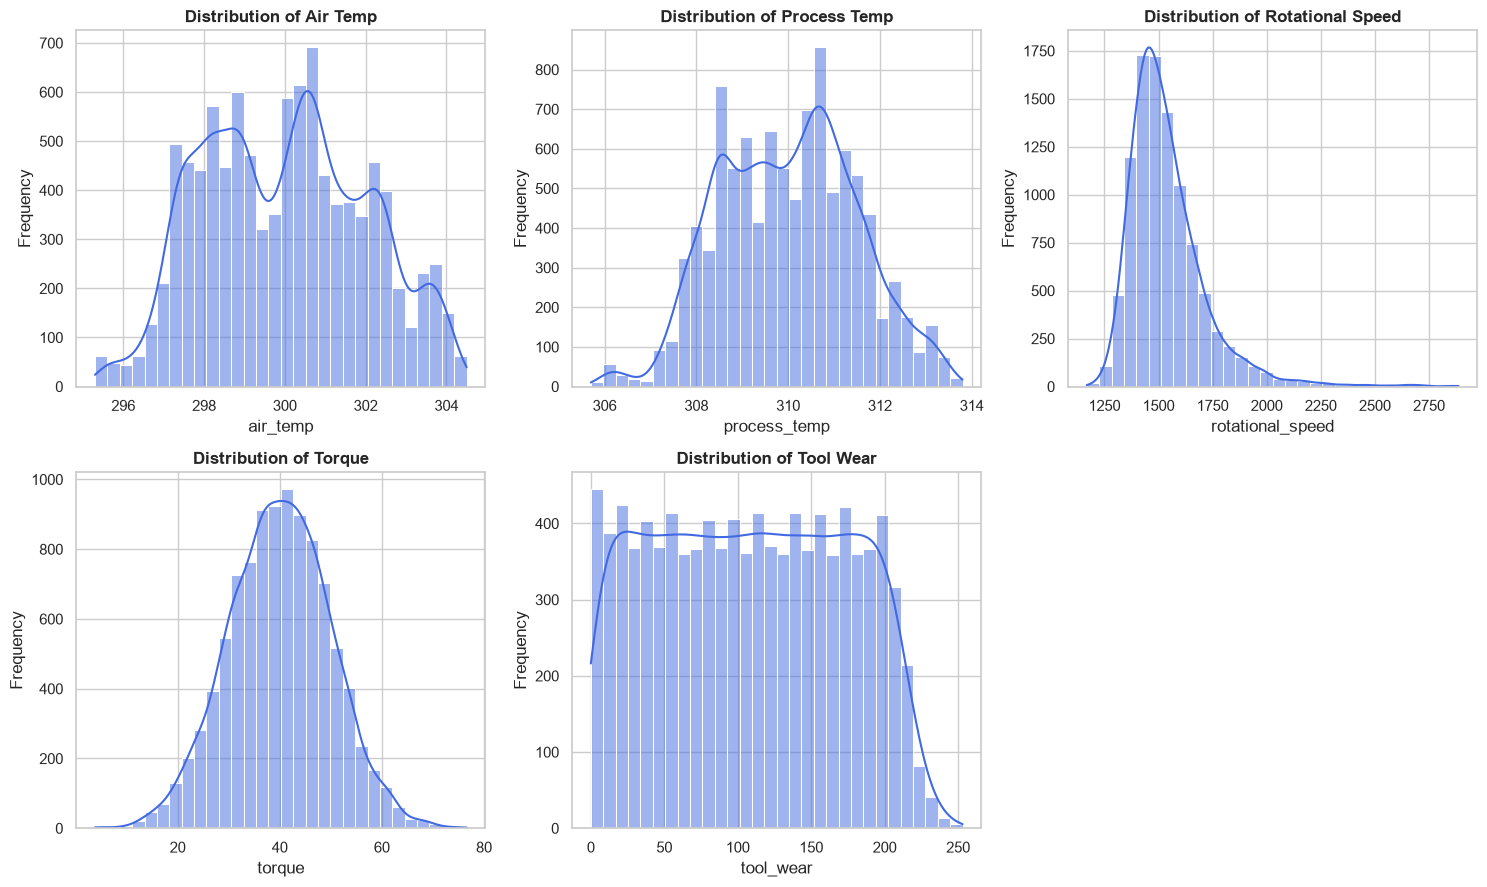

In [4]:
# Select continuous numeric sensor variables
numeric_vars = ['air_temp', 'process_temp', 'rotational_speed', 'torque', 'tool_wear']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_vars):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color='royalblue', bins=30)
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove unused 6th subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

**Air Temperature** - Approximately symmetric, near a normal distribution centered around 300K with the range 295K-304K.
The air temperature represents the ambient temperature in the facility. As the temperature shifts during seasonal and daily changes, without extreme sudden shifts the values naturally cluster around the mean.

**Process Temp** - Symmetric and near normal centered around 310K.
The process temperature is consistentl higher than air temperature due to the heat generated from machine cycles.

**Rotational Speed** - Strongly right-skewed (positively skewed) with a prominent peak around 1,400 to 1,500 RPM and a long tail extending past 2,800 RPM.
Most equipment cycles run at standard, consistent speeds, around (1500rpm). The elongated right tail signifies low torque, high speed machining tasks or occasional free spining.

**Torque** - Highly symmetric, bell-shaped distribution centered closely around 40 Nm, spanning roughly 3 Nm to nearly 80 Nm.
Due to the inverse mechanical relationship between torque and rotational speed (Power=Torque*RPM), torque balances out cleanly around a designed baseline resistance of 40 Nm. Its symmetry makes it the most well-behaved continuous variable in the dataset, which directly justifies selecting torque for the subsequent parametric normality tests (Q-Q plot, Shapiro-Wilk, F-test, and t-test).

**Tool Wear** - Approximately uniform distribution (flat profile) across the entire range from 0 to roughly 200–240 minutes, followed by a sharp drop-off.
Unlike temperature or torque (which are physical state measurements governed by natural variation), tool wear is an accumulated run-time metric. Because tools are inspected and continuously rotated or replaced once they reach their maximum recommended lifespan (around 200–240 minutes), machines are observed at roughly equal probabilities at any stage of a tool's lifecycle.

## Is Torque Shaped Like a Bell Curve? (Normality Check)

### Where our question came from
Our goal is to help factory managers catch machine breakdowns **before** they happen.
**Torque** is the twisting force on the machine's cutting tool, like how hard you twist a tight jar lid.

Two things from our earlier steps pointed us to torque:
1. In the histograms, torque was the sensor whose shape looked most like a **bell curve**.
2. The failure breakdown showed that many failures (overstrain and power failures) come from pushing the machine too hard.

So our question is:

> **Do machines that fail run at a higher torque than machines that don't?**

### Our plan, step by step
| Step | Test | Question it answers | Why we need it |
|---|---|---|---|
| 1 | **Shapiro-Wilk + Q-Q plot** (this section) | Is torque shaped like a bell curve? | The next two tests were designed for bell-shaped data, so we check that first. |
| 2 | **F-test** | Are the torque readings in the two groups **spread out** by the same amount? | Tells us which kind of t-test to use: the regular one (equal spread) or Welch's (unequal spread). |
| 3 | **t-test** | Is the gap between the two **averages** real, or just luck? | Answers our main question. |

**Why not just compare the averages?** Failed machines averaged **50.2 Nm** of torque and healthy ones averaged **39.6 Nm**. But gaps can happen by luck: flip a coin 10 times and you might get 7 heads without the coin being unfair. The t-test tells us whether our gap is **too big to be luck**.

### What is a "normal distribution" (bell curve)?
Most values sit near the middle, values get rarer the further you go from the middle, and both sides mirror each other. The heights of students in one grade are a classic example.

### Hypotheses: do we need them?
**Yes.** A p-value only means something once we say what "nothing interesting is happening" looks like.
- **$H_0$ (null hypothesis):** the boring default, "nothing is going on."
- **$H_a$ (alternative hypothesis):** what we believe instead **if** the evidence against $H_0$ is strong enough.

Each test has its own pair:

| Test | $H_0$ (default) | $H_a$ (alternative) |
|---|---|---|
| Shapiro-Wilk | Torque follows a bell curve | Torque does **not** follow a bell curve |
| F-test | Both groups have the **same** spread | The groups have **different** spreads |
| t-test | Both groups have the **same** average torque | Failed machines have a **different** average torque |

Note: Shapiro-Wilk is "backwards" from the other two. Here we **hope to keep** $H_0$, because we want the data to be bell-shaped.

### What is a p-value, and how is it calculated?
The p-value answers one question: **"If $H_0$ were true, how likely is a result at least this extreme, just by luck?"**

1. **Calculate a score from the data**: W for Shapiro-Wilk, F for the F-test, t for the t-test. The score measures how far our data is from what $H_0$ predicts.
2. **Compare the score to a "luck curve."** Statisticians already know what scores look like when $H_0$ is true and only luck is at work.
3. **The p-value is the share of that curve that is as extreme as our score, or more.** Python's `scipy.stats` does this lookup for us.

We pick a cut-off before we look: **α = 0.05 (5%)**.
- **p < 0.05**: too unlikely to be luck, so we **reject $H_0$**.
- **p ≥ 0.05**: it could be luck, so we **keep $H_0$**. This doesn't *prove* $H_0$; we just have no strong evidence against it.

Tip: a p-value like `8.1e-09` means 0.0000000081, which is basically zero.

### What does the Shapiro-Wilk test do?
It lines up every torque value from smallest to largest and compares them with where they **would** fall on a perfect bell curve. It gives a score **W between 0 and 1**: the closer W is to 1, the more bell-shaped the data. The p-value then tells us whether the gap between W and 1 is bigger than luck would explain.

### What does the Q-Q plot show?
It shows the same comparison as a picture. Each dot is one real torque value (up the side) plotted against where a perfect bell curve says it should be (along the bottom).
- **Dots on the red line:** bell-shaped.
- **Dots bending away from the line:** not bell-shaped, and **where** they bend tells us **how** the data is different.

### Why use both?
The test gives a **yes/no** answer. The plot shows **where and how much** the data differs. With thousands of data points the test acts like a very powerful magnifying glass: it can flag differences too tiny to matter. The plot tells us whether a difference is big enough to care about.

We test **all runs**, then **healthy** and **failed** machines separately, because the F-test and t-test compare those two groups.


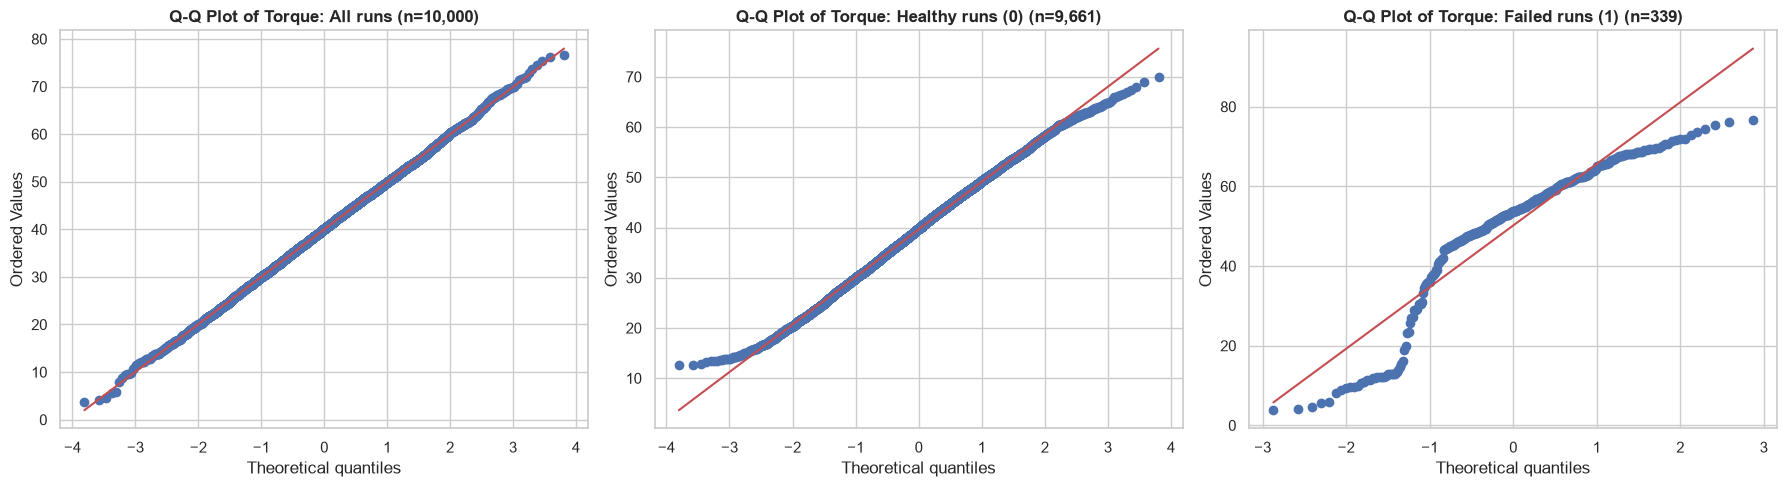

/Users/namy/Desktop/SCHOOL/Data Analysis Math/Assignments/Group1-PROG8431-ProblemAnalysis_Workshop_A/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.
  res = hypotest_fun_out(*samples, **kwds)
/Users/namy/Desktop/SCHOOL/Data Analysis Math/Assignments/Group1-PROG8431-ProblemAnalysis_Workshop_A/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9661.
  res = hypotest_fun_out(*samples, **kwds)


,Group,n,W statistic,p-value,Normal at 5%?
0,All runs,10000,0.9998,3.824474e-01,Yes
1,Healthy runs (0),9661,0.9983,8.100990e-09,No
2,Failed runs (1),339,0.8806,1.425004e-15,No


In [ ]:
# Normality assessment of torque (Q-Q plots + Shapiro-Wilk)
# The F-test and t-test compare healthy vs failed runs, so each group is checked separately.
torque = df_clean["torque"]
groups = {
    "All runs": torque,
    "Healthy runs (0)": torque[df_clean["machine_failure"] == 0],
    "Failed runs (1)": torque[df_clean["machine_failure"] == 1],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (label, values) in zip(axes, groups.items()):
    stats.probplot(values, dist="norm", plot=ax)
    ax.set_title(f"Q-Q Plot of Torque: {label} (n={len(values):,})", fontweight="bold")
plt.tight_layout()
plt.show()

# Shapiro-Wilk: H0 = the data come from a normal distribution
alpha = 0.05
rows = []
for label, values in groups.items():
    w_stat, p_value = stats.shapiro(values)
    rows.append({
        "Group": label,
        "n": len(values),
        "W statistic": round(w_stat, 4),
        "p-value": p_value,
        "Normal at 5%?": "Yes" if p_value > alpha else "No",
    })
display(pd.DataFrame(rows))

### What We Found (Normality Interpretation)

**All 10,000 runs:** the dots sit right on the red line, and W = 0.9998 with p = 0.38. That is above 0.05, so we keep $H_0$: overall, torque is bell-shaped.

**Healthy machines (9,661 runs):** W = 0.998, almost perfect, yet p < 0.001. With this many runs, the test notices even tiny gaps. Only the ends of the line bend, because healthy machines rarely run at extreme torque.

**Failed machines (339 runs):** W = 0.88, p < 0.001, so they are clearly **not** bell-shaped. They form two clusters: low-torque power failures and high-torque overstrain failures.

**What this means for the next steps:** the F-test is fussy about bell shapes, so we read its result with some caution. The t-test is still safe: with groups this large, **averages** behave like a bell curve even when the raw data doesn't (the Central Limit Theorem).

## Do Failed and Healthy Machines Have the Same Spread of Torque? (F-Test)

The t-test comes in two versions: one assumes both groups have the same variance, the other (**Welch's**) does not. The F-test tells us which one to use.

- **$H_0$:** the torque variance of failed and healthy machines is equal.
- **$H_a$:** the variances are different.
- **Score:** $F = s^2_{failed} / s^2_{healthy}$, compared against the F distribution with $(n_1 - 1, n_2 - 1)$ degrees of freedom. `scipy` has no ready-made two-sample F-test, so we compute it directly and use a two-tailed p-value.
- **Cross-check:** the F-test is sensitive to non-bell-shaped data (and failed machines were not bell-shaped in 6.e), so we also run Levene's test, which is more robust.

Variance (failed):  268.12   n = 339
Variance (healthy): 89.72   n = 9,661
F = 2.988, df = (338, 9660), p-value = 4.225e-63
Levene cross-check: statistic = 149.16, p-value = 4.623e-34
Equal variances at 5%? No -> Welch t-test in 6.g


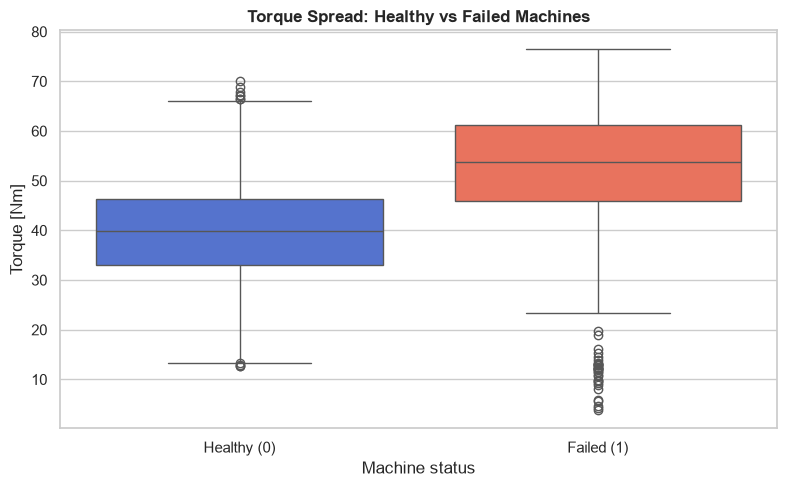

In [ ]:
# F-test for equality of torque variances (failed vs healthy)
failed = df_clean.loc[df_clean["machine_failure"] == 1, "torque"]
healthy = df_clean.loc[df_clean["machine_failure"] == 0, "torque"]

var_failed = failed.var(ddof=1)
var_healthy = healthy.var(ddof=1)
dfn, dfd = len(failed) - 1, len(healthy) - 1

# F statistic and two-tailed p-value from the F distribution
f_stat = var_failed / var_healthy
p_f = 2 * min(stats.f.cdf(f_stat, dfn, dfd), stats.f.sf(f_stat, dfn, dfd))

# Robust cross-check (does not assume normality)
lev_stat, p_levene = stats.levene(failed, healthy)

# The F-test result decides which t-test to use in 6.g
equal_var = p_f >= alpha

print(f"Variance (failed):  {var_failed:.2f}   n = {len(failed):,}")
print(f"Variance (healthy): {var_healthy:.2f}   n = {len(healthy):,}")
print(f"F = {f_stat:.3f}, df = ({dfn}, {dfd}), p-value = {p_f:.3e}")
print(f"Levene cross-check: statistic = {lev_stat:.2f}, p-value = {p_levene:.3e}")
print(f"Equal variances at {alpha:.0%}? {'Yes' if equal_var else 'No'} -> "
      f"{'pooled Student' if equal_var else 'Welch'} t-test in 6.g")

status = df_clean["machine_failure"].map({0: "Healthy (0)", 1: "Failed (1)"})

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x=status, y=df_clean["torque"], hue=status, palette=["royalblue", "tomato"], legend=False, ax=ax)
ax.set_title("Torque Spread: Healthy vs Failed Machines", fontweight="bold")
ax.set_xlabel("Machine status")
ax.set_ylabel("Torque [Nm]")
plt.tight_layout()
plt.show()

### What We Found (F-Test Summary)

The F-test gives F = 2.99 with p ≈ 4e-63, far below 0.05, so we reject equal variances. Failed machines' torque (variance 268.1) is about three times more spread out than healthy machines' (89.7). Levene's test agrees, so the next step uses Welch's t-test instead of the pooled version.

## Do Failed Machines Run at a Higher Torque? (Welch's t-Test)

- **$H_0$:** the average torque of failed and healthy machines is the same.
- **$H_a$:** the average torques are different (two-sided, as stated in 6.e). We also report a one-sided p-value for "failed machines are **higher**", which is our actual business question.
- **Score:** $t = (\bar{x}_{failed} - \bar{x}_{healthy}) / \sqrt{s^2_{failed}/n_1 + s^2_{healthy}/n_2}$. Because the F-test found unequal variances, we use Welch's version (`equal_var=False`), which adjusts the degrees of freedom.
- **Why the t-test is safe here:** with 339 and 9,661 runs, the Central Limit Theorem makes the *averages* bell-shaped even though failed-machine torque is not.

In [ ]:
# Two-sample t-test on mean torque (failed vs healthy)
# equal_var comes from the F-test in 6.f, so Welch is used when variances differ
t_stat, p_t = stats.ttest_ind(failed, healthy, equal_var=equal_var)
_, p_t_greater = stats.ttest_ind(failed, healthy, equal_var=equal_var, alternative="greater")

mean_failed, mean_healthy = failed.mean(), healthy.mean()
mean_diff = mean_failed - mean_healthy

# Welch-Satterthwaite degrees of freedom and 95% confidence interval for the difference
se_f, se_h = var_failed / len(failed), var_healthy / len(healthy)
if equal_var:
    t_df = len(failed) + len(healthy) - 2
else:
    t_df = (se_f + se_h) ** 2 / (se_f ** 2 / dfn + se_h ** 2 / dfd)
se_diff = np.sqrt(se_f + se_h)
ci_low, ci_high = mean_diff + np.array([-1, 1]) * stats.t.ppf(0.975, t_df) * se_diff

print(f"Test used: {'Student (pooled)' if equal_var else 'Welch'} two-sample t-test")
print(f"Mean torque (failed):  {mean_failed:.2f} Nm")
print(f"Mean torque (healthy): {mean_healthy:.2f} Nm")
print(f"Difference: {mean_diff:.2f} Nm, 95% CI [{ci_low:.2f}, {ci_high:.2f}]")
print(f"t = {t_stat:.3f}, df = {t_df:.1f}")
print(f"Two-sided p-value = {p_t:.3e}")
print(f"One-sided p-value (failed > healthy) = {p_t_greater:.3e}")
print(f"Reject H0 at {alpha:.0%}? {'Yes' if p_t < alpha else 'No'}")

Test used: Welch two-sample t-test
Mean torque (failed):  50.17 Nm
Mean torque (healthy): 39.63 Nm
Difference: 10.54 Nm, 95% CI [8.78, 12.30]
t = 11.781, df = 346.0
Two-sided p-value = 3.636e-27
One-sided p-value (failed > healthy) = 1.818e-27
Reject H0 at 5%? Yes


### What We Found (t-Test Summary)

Welch's t-test gives t = 11.78 (df ≈ 346) and p ≈ 4e-27, so we reject equal means. Failed machines average 50.2 Nm versus 39.6 Nm for healthy ones, about 10.5 Nm higher. Failed machines clearly run at higher torque, although this shows association, not cause, so torque is a useful early-warning signal.